In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("weather_training_1000.csv")

# Lihat data awal
print(df.head())
print(df['label_cuaca'].value_counts())

    suhu  kelembapan   cahaya  hujan label_cuaca
0  23.33       98.55  1006.40   0.58       hujan
1  25.09       49.15  1860.44   0.09       cerah
2  21.28       89.70  1497.26   0.44       hujan
3  21.34       89.30  1531.84   0.02       hujan
4  21.35       57.64   968.06   0.53     berawan
label_cuaca
hujan      454
berawan    298
cerah      248
Name: count, dtype: int64


In [115]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   suhu         1000 non-null   float64
 1   kelembapan   1000 non-null   float64
 2   cahaya       1000 non-null   float64
 3   hujan        1000 non-null   float64
 4   label_cuaca  1000 non-null   object 
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


suhu           0
kelembapan     0
cahaya         0
hujan          0
label_cuaca    0
dtype: int64

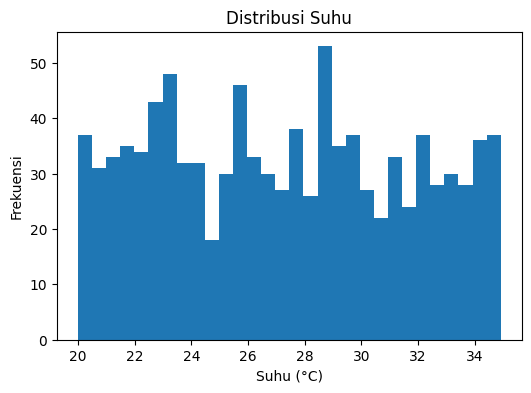

In [116]:
plt.figure(figsize=(6,4))
plt.hist(df['suhu'], bins=30)
plt.title("Distribusi Suhu")
plt.xlabel("Suhu (°C)")
plt.ylabel("Frekuensi")
plt.show()

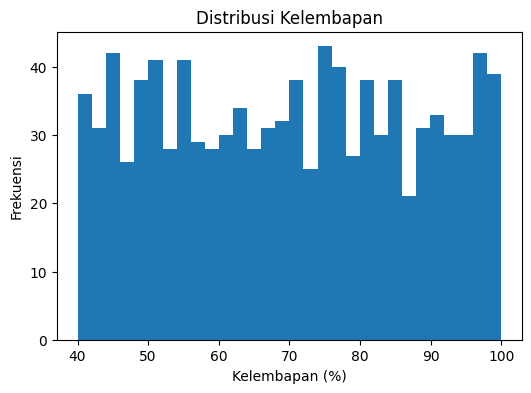

In [117]:
plt.figure(figsize=(6,4))
plt.hist(df['kelembapan'], bins=30)
plt.title("Distribusi Kelembapan")
plt.xlabel("Kelembapan (%)")
plt.ylabel("Frekuensi")
plt.show()


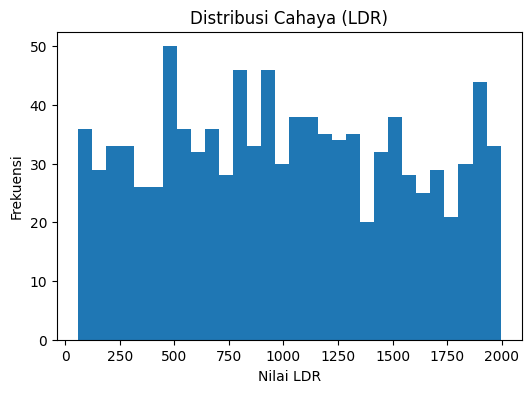

In [118]:
plt.figure(figsize=(6,4))
plt.hist(df['cahaya'], bins=30)
plt.title("Distribusi Cahaya (LDR)")
plt.xlabel("Nilai LDR")
plt.ylabel("Frekuensi")
plt.show()


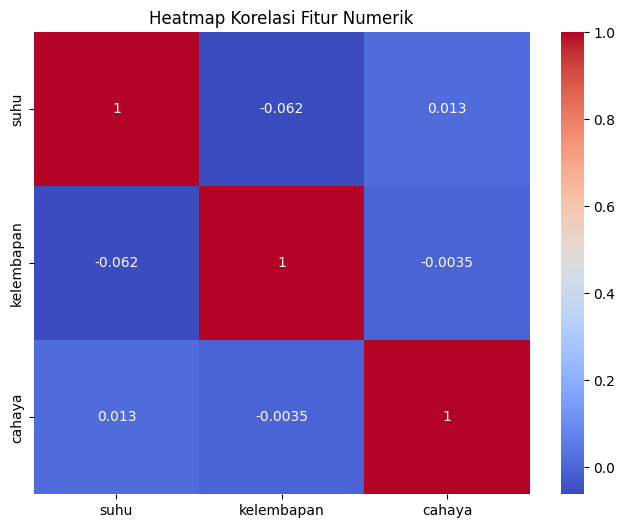

In [119]:
numeric_df = df[["suhu", "kelembapan", "cahaya"]]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

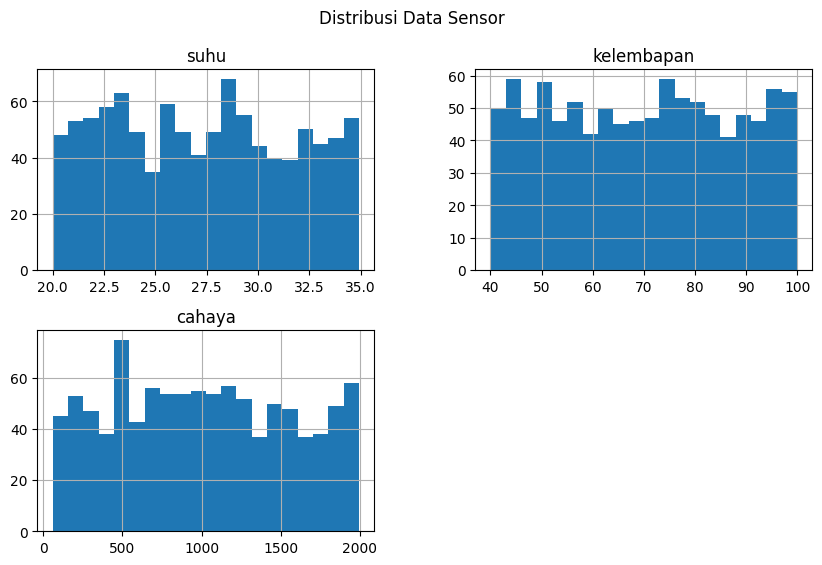

In [120]:
numeric_df.hist(figsize=(10,6), bins=20)
plt.suptitle("Distribusi Data Sensor")
plt.show()


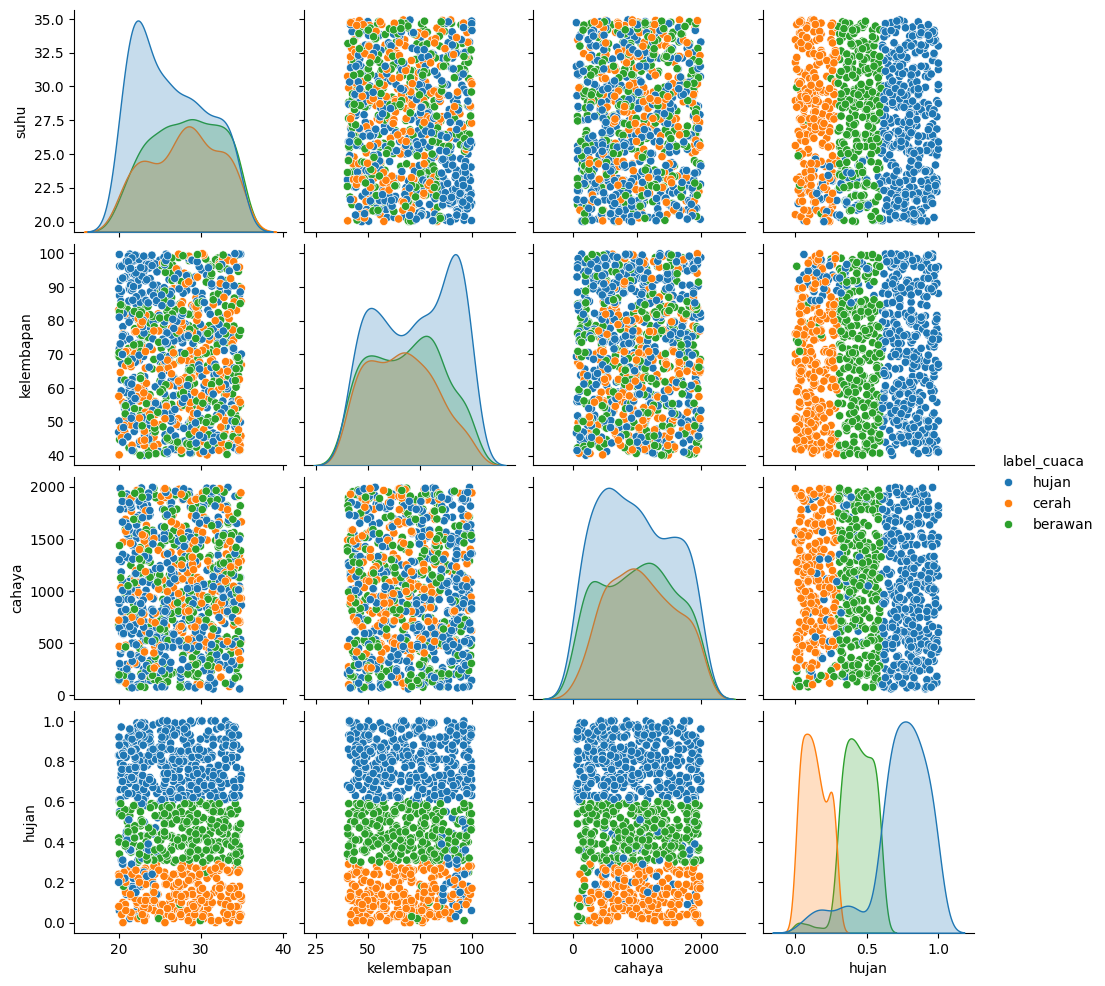

In [121]:
sns.pairplot(df, hue="label_cuaca")
plt.show()

In [133]:
sns.pairplot(df, hue="label_cuaca")
plt.savefig("assets/pairplot.png")  # simpan di folder web
plt.close()

In [122]:
X = df[["suhu", "kelembapan", "cahaya"]]
y = df["label_cuaca"]

In [123]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [124]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [125]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y_encoded)

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [127]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42
)
model.fit(X_train, y_train)

c:\xampp\htdocs\smart_home\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:59:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [128]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.5421245421245421
              precision    recall  f1-score   support

     berawan       0.54      0.56      0.55        91
       cerah       0.56      0.59      0.58        91
       hujan       0.52      0.47      0.49        91

    accuracy                           0.54       273
   macro avg       0.54      0.54      0.54       273
weighted avg       0.54      0.54      0.54       273



In [132]:
pickle.dump(model, open("model_cuaca.pkl", "wb"))